In [1]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import random
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, matthews_corrcoef
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from mantis.architecture import MantisV2
from mantis.trainer import MantisTrainer
from sklearn.model_selection import GroupKFold


# 強制指向你的專案根目錄 (Mantis 資料夾的上一層)
project_root = r"F:\M143020071\MI\program"
if project_root not in sys.path:
    sys.path.append(project_root)

# 使用別名 mantis_tool，後面呼叫比較方便
from Mantis import single_channel_extract_feats as mantis_tool

In [2]:
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denom = tp + tn + fp + fn
    acc = (tp + tn) / denom if denom > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    return [acc, sens, spec, mcc]

def evaluate_predictions(y_true, y_prob, groups, threshold=0.5):
    """統一處理 Window-level 與 Subject-level 的指標計算"""
    win_metrics = get_metrics(y_true, (y_prob >= threshold).astype(int))
    
    # 計算 Subject-level (以受試者平均機率判定)
    df = pd.DataFrame({'ID': groups, 'Actual': y_true, 'Prob': y_prob}).groupby('ID').mean()
    sub_metrics = get_metrics(df['Actual'], (df['Prob'] >= threshold).astype(int))
    
    return win_metrics, sub_metrics, df

def load_data_with_groups(MI_path, non_MI_path):
    X, y, groups = [], [], []
    for path, label in [(MI_path, 1), (non_MI_path, 0)]:
        if not os.path.exists(path): continue
        for file in [f for f in os.listdir(path) if f.endswith('.npy')]:
            data = np.load(os.path.join(path, file))[:, 1:].astype(np.float32)  # 假設第一欄是時間戳，丟掉
            X.append(data)
            y.append(np.full(len(data), label))
            groups.extend([file] * len(data))
    return np.vstack(X), np.concatenate(y), np.array(groups)


def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-MI(0)', 'MI(1)'], 
                yticklabels=['Non-MI(0)', 'MI(1)'], ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

def save_cm_to_csv(y_true, y_pred, filename):
    """計算混淆矩陣並存成 CSV"""
    cm = confusion_matrix(y_true, y_pred)
    # 建立 DataFrame 並加入行列標籤增加可讀性
    cm_df = pd.DataFrame(cm, 
                         index=['Actual_0', 'Actual_1'], 
                         columns=['Predicted_0', 'Predicted_1'])
    full_path = os.path.join(save_path, f"{filename}.csv")
    cm_df.to_csv(full_path)
    print(f"Saved: {full_path}")

In [3]:
feat_dir = r'D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature'
save_path = r'D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results'
categories = ['non_MI', 'MI', 'non_MACE', 'MACE']
seed = 42
random.seed(seed)
np.random.seed(seed)

if not os.path.exists(save_path):
    os.makedirs(save_path)

In [4]:
X_list, y_list, group_list, cat_tag_list = [], [], [], []

for cat in categories:
    path = os.path.join(feat_dir, f'features_{cat}_1024.npy')
    if os.path.exists(path):
        
        data = np.load(path, allow_pickle=True)
        X_list.append(data[:, 2:].astype(float))
        y_list.append(data[:, 1].astype(float).astype(int))
        group_list.append(data[:, 0])
        cat_tag_list.append(np.array([cat] * len(data)))
        print(f"Loaded {cat}: {len(np.unique(data[:, 0]))} persons")

X_raw = np.concatenate(X_list, axis=0)
y_raw = np.concatenate(y_list, axis=0)
groups_raw = np.concatenate(group_list, axis=0)
cats_raw = np.concatenate(cat_tag_list, axis=0)

X_raw_resized = mantis_tool.resize(X_raw)
print(f"Resized features shape: {X_raw_resized.shape}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
network = MantisV2(device=device, return_transf_layer=0, output_token='combined')
network = network.from_pretrained("paris-noah/MantisV2")
model_trainer = MantisTrainer(device=device, network=network)

Loaded non_MI: 200 persons
Loaded MI: 200 persons
Loaded non_MACE: 432 persons
Loaded MACE: 90 persons
Resized features shape: (134612, 1, 512)


In [5]:
u_non_mi = np.unique(groups_raw[cats_raw == 'non_MI'])
u_non_mace = np.unique(groups_raw[cats_raw == 'non_MACE'])
u_mace = np.unique(groups_raw[cats_raw == 'MACE'])


train_non_mace_ids = random.sample(list(u_non_mace), 200)
train_ids = list(u_non_mi) + train_non_mace_ids

test_non_mace_ids = [i for i in u_non_mace if i not in train_non_mace_ids]
test_ids = test_non_mace_ids + list(u_mace)

train_mask = np.isin(groups_raw, train_ids)
test_mask = np.isin(groups_raw, test_ids)

print(f"\n[Split Summary] Train Subjects: {len(train_ids)}, Test Subjects: {len(test_ids)}")


[Split Summary] Train Subjects: 400, Test Subjects: 322


In [6]:
hyper_params_dict = {
    'objective': 'binary:logistic',
    'booster': 'gbtree', 
    'eval_metric': 'aucpr', 
    'learning_rate': 0.05, 
    'n_estimators': 500, 
    'max_depth': 3, 
    'min_child_weight': 1,
    'gamma': 0.1, 
    'subsample': 0.8, 
    'colsample_bytree': 0.8, 
    'reg_alpha': 0.01, 
    'reg_lambda': 1, 
    'random_state': 42
}


========== Processing MantisV2 Layer 1 ==========
Extracting features...
Training XGBoost on Train set...


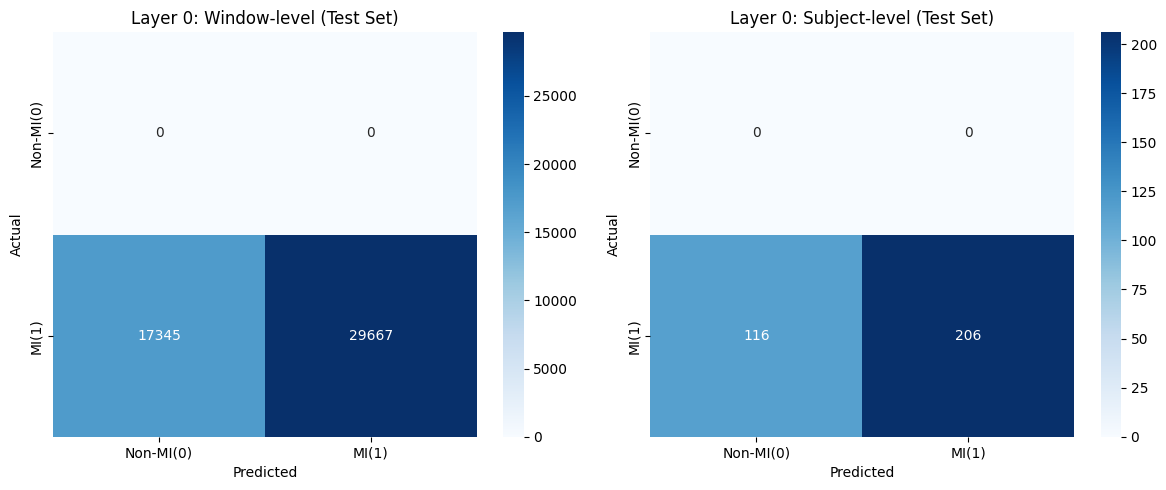

Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_win_layer_0.csv
Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_sub_layer_0.csv

========== Processing MantisV2 Layer 2 ==========
Extracting features...
Training XGBoost on Train set...


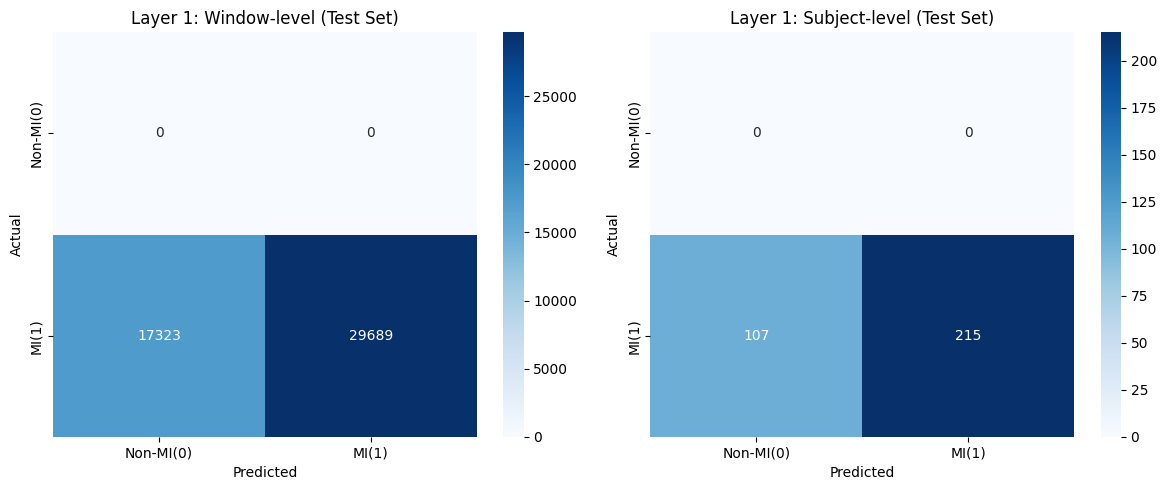

Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_win_layer_1.csv
Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_sub_layer_1.csv

========== Processing MantisV2 Layer 3 ==========
Extracting features...
Training XGBoost on Train set...


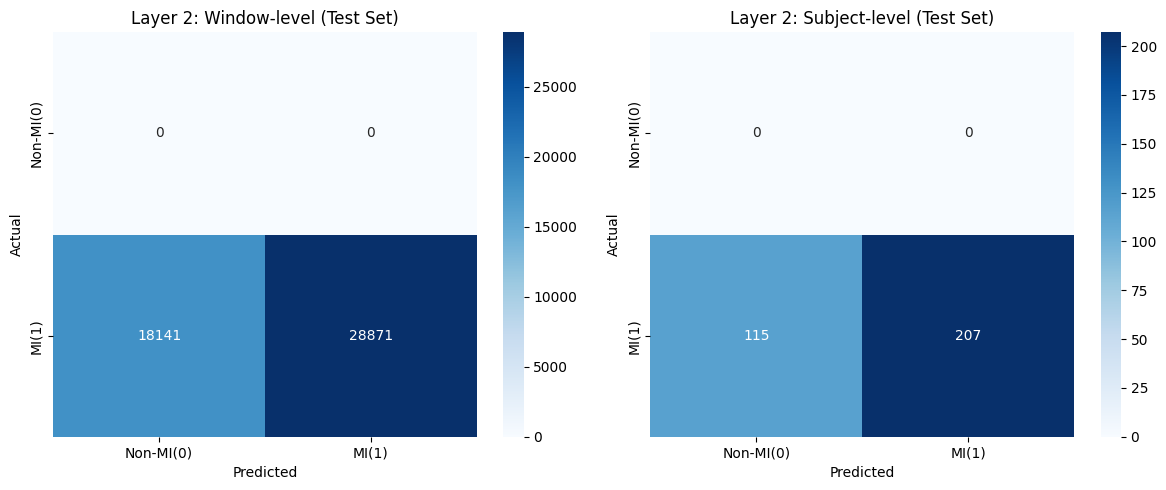

Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_win_layer_2.csv
Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_sub_layer_2.csv

========== Processing MantisV2 Layer 4 ==========
Extracting features...
Training XGBoost on Train set...


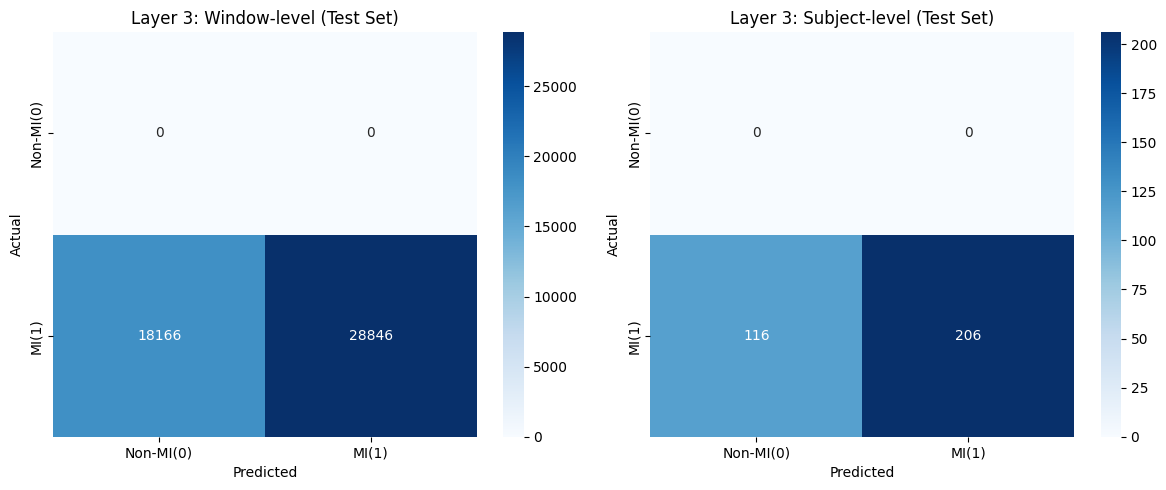

Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_win_layer_3.csv
Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_sub_layer_3.csv

========== Processing MantisV2 Layer 5 ==========
Extracting features...
Training XGBoost on Train set...


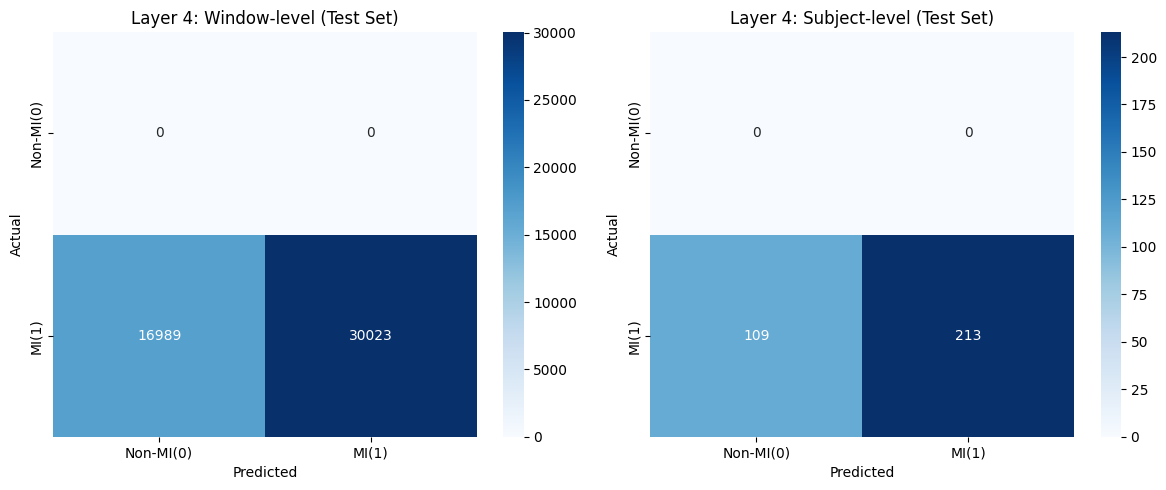

Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_win_layer_4.csv
Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_sub_layer_4.csv

========== Processing MantisV2 Layer 6 ==========
Extracting features...
Training XGBoost on Train set...


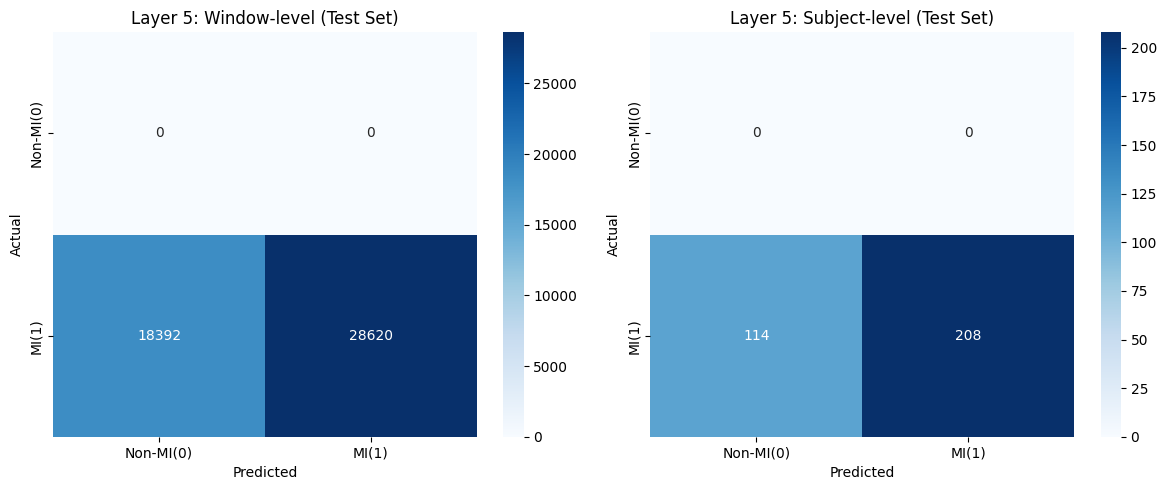

Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_win_layer_5.csv
Saved: D:\M143020071\MACE and MI\xgboost_results\ECG_Founder_feature/results\cm_sub_layer_5.csv

========== Final Summary Across All Layers ==========


,Layer,Win_Acc,Win_Sens,Win_Spec,Win_MCC,Sub_Acc,Sub_Sens,Sub_Spec,Sub_MCC
0,0,0.631052,0.631052,0,0.0,0.639752,0.639752,0,0.0
1,1,0.631520,0.631520,0,0.0,0.667702,0.667702,0,0.0
2,2,0.614120,0.614120,0,0.0,0.642857,0.642857,0,0.0
3,3,0.613588,0.613588,0,0.0,0.639752,0.639752,0,0.0
4,4,0.638624,0.638624,0,0.0,0.661491,0.661491,0,0.0
5,5,0.608781,0.608781,0,0.0,0.645963,0.645963,0,0.0


In [ ]:
all_layer_results = []

for layer_idx in range(6):
    print(f"\n========== Processing MantisV2 Layer {layer_idx+1} ==========")
    
    # 1. 指定當前提取的 Layer 並執行特徵轉換
    network.return_transf_layer = layer_idx
    print("Extracting features...")
    X_transformed = model_trainer.transform(X_raw_resized)
    
    # 2. 根據前面切好的 Mask 分離 Train 與 Test 資料
    X_train, y_train = X_transformed[train_mask], y_raw[train_mask]
    X_test, y_test, groups_test = X_transformed[test_mask], y_raw[test_mask], groups_raw[test_mask]
    
    # 3. 建立並訓練 Pipeline (StandardScaler -> PCA -> XGBoost)
    # PCA 的 n_components 您可以依照需求調整 (這裡預設保留 95% 變異)
    pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=0.95, random_state=seed),
        XGBClassifier(**hyper_params_dict)
    )
    
    print("Training XGBoost on Train set...")
    pipeline.fit(X_train, y_train)
    
    # 4. 在 Test 集進行預測
    y_probs_test = pipeline.predict_proba(X_test)[:, 1]
    
    # 5. 雙層級評估 (Window 與 Subject)
    win_metrics, sub_metrics, df_sub = evaluate_predictions(y_test, y_probs_test, groups_test, threshold=0.5)
    
    # 紀錄結果
    all_layer_results.append({
        'Layer': layer_idx+1,
        'Win_Acc': win_metrics[0], 'Win_Sens': win_metrics[1], 'Win_Spec': win_metrics[2], 'Win_MCC': win_metrics[3],
        'Sub_Acc': sub_metrics[0], 'Sub_Sens': sub_metrics[1], 'Sub_Spec': sub_metrics[2], 'Sub_MCC': sub_metrics[3]
    })
    
    # 6. 繪製並儲存混淆矩陣
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plot_confusion_matrix(y_test, (y_probs_test >= 0.5).astype(int), 
                          f"Layer {layer_idx+1}: Window-level (Test Set)", axes[0])
    plot_confusion_matrix(df_sub['Actual'], (df_sub['Prob'] >= 0.5).astype(int), 
                          f"Layer {layer_idx+1}: Subject-level (Test Set)", axes[1])
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"cm_layer_{layer_idx+1}.png"))
    plt.show()
    
    # 輸出 CSV
    save_cm_to_csv(y_test, (y_probs_test >= 0.5).astype(int), f"cm_win_layer_{layer_idx+1}")
    save_cm_to_csv(df_sub['Actual'], (df_sub['Prob'] >= 0.5).astype(int), f"cm_sub_layer_{layer_idx+1}")

# ==========================================
# 輸出總結表
# ==========================================
print("\n========== Final Summary Across All Layers ==========")
summary_df = pd.DataFrame(all_layer_results)
display(summary_df)
summary_df.to_csv(os.path.join(save_path, "mantis_layer_summary.csv"), index=False)